# 4. Train

Loads the already horizon-stacked training frame from notebook 3 and does the three things left: a **time-based split** (never shuffled, with an embargo gap so no training label leaks into the test window -- see `src/ml/dataset.py::time_split`), fitting one XGBoost model across all horizons, and evaluating it against EIA's own forecast on the exact same test rows.

The model **never sees EIA's forecast as an input feature** -- it's only used as the baseline. Otherwise "beats the EIA forecast" wouldn't mean much.

Every run is logged to MLflow (params, both sets of metrics, the model itself) so different runs can be compared instead of just reading numbers off this notebook's output.

In [15]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [16]:
import json
import os

import joblib
import matplotlib.pyplot as plt
import mlflow
import mlflow.xgboost
import pandas as pd
import yaml
from dotenv import load_dotenv

from src.ml.dataset import FEATURE_COLUMNS, time_split
from src.ml.model import evaluate, score, train_model

load_dotenv(PROJECT_ROOT / ".env")
train_params = yaml.safe_load(open(PROJECT_ROOT / "params.yaml"))["train"]
train_params

{'test_frac': 0.2,
 'embargo_hours': 24,
 'random_state': 42,
 'lightgbm': {'num_leaves': 63, 'learning_rate': 0.05, 'n_estimators': 500},
 'xgboost': {'max_depth': 8, 'learning_rate': 0.05, 'n_estimators': 500},
 'catboost': {'depth': 8, 'learning_rate': 0.05, 'iterations': 500},
 'random_forest': {'n_estimators': 300, 'max_depth': 12}}

In [17]:
train_frame_path = PROJECT_ROOT / "data" / "processed" / "train_frame.csv"
stacked = pd.read_csv(train_frame_path, parse_dates=["demand_hour_utc"])

train_df, test_df = time_split(
    stacked,
    test_frac=train_params["test_frac"],
    embargo_hours=train_params["embargo_hours"],
)
print(
    f"train: {len(train_df):,} rows "
    f"({train_df['demand_hour_utc'].min()} -> {train_df['demand_hour_utc'].max()})"
)
print(
    f"test:  {len(test_df):,} rows "
    f"({test_df['demand_hour_utc'].min()} -> {test_df['demand_hour_utc'].max()})"
)

train: 2,503,423 rows (2021-07-12 17:00:00 -> 2025-07-06 01:00:00)
test:  622,332 rows (2025-07-07 01:00:00 -> 2026-07-04 15:00:00)


In [18]:
model_type = "xgboost"
model_params = {**train_params[model_type], "random_state": train_params["random_state"]}

mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
mlflow.set_experiment("gridcast-demand-forecast")

with mlflow.start_run(run_name=model_type) as run:
    mlflow.log_param("model_type", model_type)
    mlflow.log_params(model_params)
    mlflow.log_params(
        {
            "test_frac": train_params["test_frac"],
            "embargo_hours": train_params["embargo_hours"],
            "train_rows": len(train_df),
            "test_rows": len(test_df),
        }
    )

    model = train_model(train_df, model_type, model_params)
    test_scored, metrics = evaluate(model, test_df)

    mlflow.log_metrics({f"model_{k}": v for k, v in metrics["model"].items()})
    mlflow.log_metrics({f"baseline_{k}": v for k, v in metrics["baseline"].items()})

    by_horizon = []
    for horizon, group in test_scored.groupby("horizon"):
        h_model = score(group["target_mwh"], group["model_pred"])
        h_baseline = score(group["target_mwh"], group["baseline_mwh"])
        mlflow.log_metric("model_mae_by_horizon", h_model["mae"], step=horizon)
        mlflow.log_metric("baseline_mae_by_horizon", h_baseline["mae"], step=horizon)
        by_horizon.append(
            {"horizon": horizon, "model_mae": h_model["mae"], "baseline_mae": h_baseline["mae"]}
        )

    mlflow.xgboost.log_model(
        model, artifact_path="model", registered_model_name="gridcast-demand-forecaster-xgboost"
    )
    run_id = run.info.run_id

print(f"MLflow run: {run_id} ({model_type})")
print(f"model MAE={metrics['model']['mae']:.1f} MAPE={metrics['model']['mape']:.2%}")
print(f"baseline (EIA DF) MAE={metrics['baseline']['mae']:.1f} MAPE={metrics['baseline']['mape']:.2%}")

🏃 View run xgboost at: http://localhost:5000/#/experiments/1/runs/7e2e70486d0044baacfb3be1d350eee4
🧪 View experiment at: http://localhost:5000/#/experiments/1


TypeError: `_estimator_type` undefined.  Please use appropriate mixin to define estimator type.

### MAE by forecast horizon -- model vs. the EIA baseline

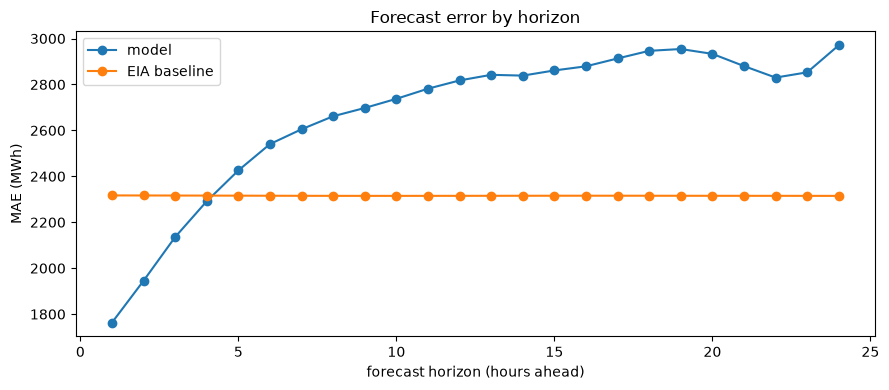

In [ ]:
by_horizon_df = pd.DataFrame(by_horizon)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(by_horizon_df["horizon"], by_horizon_df["model_mae"], marker="o", label="model")
ax.plot(by_horizon_df["horizon"], by_horizon_df["baseline_mae"], marker="o", label="EIA baseline")
ax.set_xlabel("forecast horizon (hours ahead)")
ax.set_ylabel("MAE (MWh)")
ax.set_title("Forecast error by horizon")
ax.legend()
fig.tight_layout()
plt.show()

In [ ]:
print(by_horizon_df.to_string(index=False))


 horizon   model_mae  baseline_mae
       1 1762.990189   2316.869632
       2 1945.270000   2316.664356
       3 2135.690430   2316.404368
       4 2291.683306   2316.144745
       5 2425.676680   2315.835395
       6 2540.471394   2315.493834
       7 2604.998457   2315.205303
       8 2661.657440   2315.024861
       9 2697.725208   2314.933811
      10 2737.547204   2314.920580
      11 2781.652594   2314.991787
      12 2817.603995   2315.086110
      13 2842.049857   2315.239732
      14 2838.585666   2315.396745
      15 2861.088159   2315.553254
      16 2879.074358   2315.635455
      17 2913.306847   2315.618744
      18 2946.497326   2315.501737
      19 2954.337193   2315.342712
      20 2933.258245   2315.230276
      21 2880.118216   2315.157228
      22 2830.007309   2315.076867
      23 2852.905840   2314.996023
      24 2970.990262   2314.849900


In [ ]:
pd.Series(model.feature_importances_, index=FEATURE_COLUMNS).sort_values(ascending=False)

demand_rolling_mean_24h     0.916135
demand_rolling_mean_168h    0.029162
hour_of_day                 0.010614
demand_lag_1h               0.009296
horizon                     0.008362
demand_rolling_std_24h      0.007144
day_of_week                 0.005802
demand_lag_24h              0.005069
month                       0.002665
is_holiday                  0.002471
demand_rolling_std_168h     0.002251
demand_lag_168h             0.001028
is_weekend                  0.000000
dtype: float32

In [ ]:
model_path = PROJECT_ROOT / "models" / "model_xgboost.pkl"
model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model, model_path)

metrics_out = {
    "model_mae": metrics["model"]["mae"],
    "model_mape": metrics["model"]["mape"],
    "baseline_mae": metrics["baseline"]["mae"],
    "baseline_mape": metrics["baseline"]["mape"],
    "mlflow_run_id": run_id,
}
with open(PROJECT_ROOT / "metrics_xgboost.json", "w") as f:
    json.dump(metrics_out, f, indent=2)

print(f"wrote {model_path}")
print(f"wrote {PROJECT_ROOT / 'metrics_xgboost.json'}")

NameError: name 'run_id' is not defined